## Multiscale contextualization of hippocampal gene expression gradients

**Overview**

In this tutorial, we will assess how the principal axes of transcriptomic organization align with multimodal/multiscale features of the hippocampus.

**0 - Import libraries**

In [1]:
import os
import sys 

import hippomaps as hm
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns

from brainspace.gradient import GradientMaps
from brainspace.mesh.mesh_io import read_surface
from cmcrameri import cm

sys.path.append(os.path.abspath(".."))
import hippogenes as hg

/host/yeatman/local_raid/ango/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


**1 - Load gene expression data and gradients**

In [2]:
expression = hg.load_expression(data_dir="./data")

In [3]:
# Diffusion map embedding:
gm = GradientMaps(n_components=10, kernel="normalized_angle", approach="dm")
gm = gm.fit(np.array(expression), sparsity=0.9)

**2 - Load HippoMaps features**

In [14]:
maps_dir = '/host/cassio/export03/data/jordand/publication-hippomaps/maps/HippoMaps-initializationMaps/'
gyri = nib.load(f'{maps_dir}/Dataset-MICs/MRI-3T-gyrification_average-99_hemi-L_den-0p5mm_label-hipp.shape.gii').darrays[0].data
gyri == cdata[10]

array([False, False, False, ..., False, False, False])

In [18]:
cdata[8]

array([ 0.59942726,  0.04325759,  0.03521592, ..., 11.21870562,
       10.31953711, 11.39398428])

In [4]:
maps_dir = os.path.join(".", "data", "hippomaps")
files = [
    # Histology
    "histology-Bieloschowsky_average-4_hemi-mix_den-unfoldiso_label-hipp.shape.gii",
    "histology-Blockface_average-4_hemi-mix_den-unfoldiso_label-hipp.shape.gii",
    "histology-Calbindin_average-4_hemi-mix_den-unfoldiso_label-hipp.shape.gii",
    "histology-Calretinin_average-4_hemi-mix_den-unfoldiso_label-hipp.shape.gii",
    "histology-Merker_average-4_hemi-mix_den-unfoldiso_label-hipp.shape.gii",
    "histology-Parvalbumin_average-4_hemi-mix_den-unfoldiso_label-hipp.shape.gii",
    
    # Imaging
    "MRI-3T-curvature_average-99_hemi-L_den-0p5mm_label-hipp.shape.gii",
    "MRI-3T-thickness_average-99_hemi-L_den-0p5mm_label-hipp.shape.gii",
    "MRI-3T-gyrification_average-99_hemi-L_den-0p5mm_label-hipp.shape.gii",
    "MRI-3T-DTI-FA_average-82.0_hemi-L_den-0p5mm_label-hipp.shape.gii",
    "MRI-3T-DTI-ADC_average-82.0_hemi-L_den-0p5mm_label-hipp.shape.gii",
    "MRI-3T-qT1_average-89.0_hemi-L_den-0p5mm_label-hipp.shape.gii",
    "MRI-7T-T2star_average-20_hemi-mix_den-0p5mm_label-hipp.shape.gii",
    "MRI-3T-rsfMRI-FCG1to5_average-80_hemi-L_den-2mm_label-hipp.shape.gii"
 ]

In [5]:
maps = []

for f in files:
    feat = f.split("_")[0].split("-")[-1]
    den = f.split("den-")[1].split("_")[0]

    gii = nib.load(os.path.join(maps_dir, f)).darrays[0].data

    if feat == "FCG1to5":
        maps.append({
            "feature": f"{feat}_grad1",
            "density": den,
            "data": gii[:, 0],
        })
        
            {"feature": f"{feat}_grad2", "density": den, "data": gii[:, 1]},
        ])
    else:
        maps.append({
            "feature": feat,
            "density": den,
            "data": gii,
        })

In [19]:
cdata[features.index("gyrification")]

array([ 0.59942726,  0.04325759,  0.03521592, ..., 11.21870562,
       10.31953711, 11.39398428])

In [9]:
_, _, test_pval, test_corr = hm.stats.eigenstrapping(cdata[features.index("gyrification")], gm.gradients_[:,1], nperm=nperm, label="hipp", den="0p5mm")
test_pval, test_corr

(0.015, -0.494950750828971)

In [67]:
_, _, test_pval, test_corr = hm.stats.eigenstrapping(cdata[j], gm.gradients_[:,1], nperm=nperm, label="hipp", den="0p5mm")
test_pval, test_corr

(0.145, -0.19276513594480874)

In [66]:
_, _, test_pval, test_corr = hm.stats.eigenstrapping(cdata[j], gm.gradients_[:,0], nperm=nperm, label="hipp", den="0p5mm")
test_pval, test_corr

(0.213, 0.19395827738438365)

In [22]:
cdata[10]

array([ 0.59942726,  0.04325759,  0.03521592, ..., 11.21870562,
       10.31953711, 11.39398428])

In [19]:
nib.load(os.path.join(maps_dir, "MRI-3T-gyrification_average-99_hemi-L_den-0p5mm_label-hipp.shape.gii")).darrays[0].data

array([ 0.59942726,  0.04325759,  0.03521592, ..., 11.21870562,
       10.31953711, 11.39398428])

In [12]:
features = []
densities = []
cdata = []
for f in files:    
    
    feat = f.split("_")[0].split("-")[-1]
    den = f.split("den-")[1].split("_")[0]
    
    gii = nib.load(os.path.join(maps_dir, f)).darrays[0].data

    if feat == "FCG1to5":
        cdata.append(gii[:,0])
        cdata.append(gii[:,1])

        features.append(f"{feat}_grad1")
        features.append(f"{feat}_grad2")
        densities.append(den)
        densities.append(den)
    else: 
        cdata.append(gii)
        densities.append(den)
        features.append(feat)

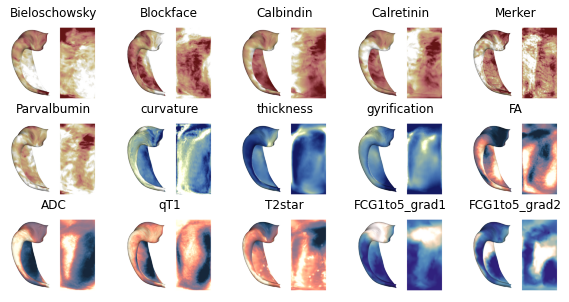

In [6]:
cmap = {
        # Histoloty
        "Bieloschowsky": cm.bilbao, 
        "Blockface": cm.bilbao, 
        "Parvalbumin": cm.bilbao, 
        "Calbindin": cm.bilbao, 
        "Calretinin": cm.bilbao,
        "Merker": cm.bilbao,
        
        # Morphology
        "curvature": cm.davos,
        "thickness": cm.davos,
        "gyrification": cm.davos,
        
        # Function
        "FCG1to5_grad1": cm.lapaz,
        "FCG1to5_grad2": cm.lapaz,
        
        # Microstructure
        "FA": cm.lipari,
        "ADC": cm.lipari,
        "qT1": cm.lipari,
        "T2star": cm.lipari
}
        

fig, ax = plt.subplots(3, 5, figsize=(10, 5))
for i, feat in enumerate(features):
    x = hm.utils.density_interp(densities[i], '0p5mm', cdata[i], label="hipp") if densities[i] != "0p5mm" else cdata[i]
    hm.plotting.surfplot_canonical_foldunfold(x, cmap=cmap[feat], hemis=["L"], labels=["hipp"], unfoldAPrescale=True, 
                                              share="row", tighten_cwindow=True, screenshot=True, filename=f"tmp_{i}.png")
    
    f = plt.imread(f"tmp_{i}.png")   
    ax[i//5, i%5].imshow(f)
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_anchor("NW")
    ax[i//5, i%5].set_title(feat)
    
!rm tmp_*.png

**3 - Correlate multimodal hippocampal maps with transcriptomic gradients**

In [23]:
# Statistical testing
nperm = 1000

gene_contextualization = {}

for i in range(2):

    corr = np.full(len(cdata), np.nan)
    pval = np.full(len(cdata), np.nan)
    null = np.full((len(cdata), nperm), np.nan)
    
    for j, feat in enumerate(features):
        
        map1 = cdata[j].copy()
        map2 = gm.gradients_[:,i].copy()
        den = "0p5mm"
        
        if densities[j] == "2mm":
            den = "2mm"
            map2 = hm.utils.density_interp('0p5mm', '2mm', map2, label="hipp")
        elif densities[j] == "unfoldiso":
            map1= hm.utils.density_interp("unfoldiso", '0p5mm', map1, label="hipp")

        null[j,:], _, pval[j], corr[j] = hm.stats.eigenstrapping(map1, map2, nperm=nperm, label="hipp", den=den)
        
    gene_contextualization[f"gene_gradient{i+1}"] = {"corr": corr, "pval": pval, "null": null}

(0.0, 1.0)

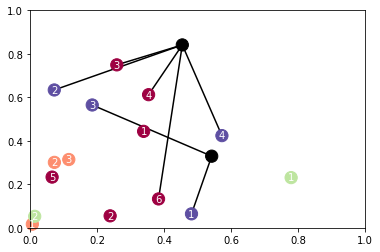

In [24]:
data = {
        #Transcriptomics
        "gene_gradient1": {"modality": "transcriptomics", "color": "#000000"},
        "gene_gradient2": {"modality": "transcriptomics", "color": "#000000"},

        # Histoloty
        "Bieloschowsky": {"modality": "histology", "color": "#9E0142"},
        "Blockface": {"modality": "histology", "color": "#9E0142"},
        "Parvalbumin": {"modality": "histology", "color": "#9E0142"},
        "Calbindin": {"modality": "histology", "color": "#9E0142"},
        "Calretinin": {"modality": "histology", "color": "#9E0142"},
        "Merker": {"modality": "histology", "color": "#9E0142"},
        
        # Morphology
        "curvature": {"modality": "morphology", "color": "#FD8E6F"},
        "thickness": {"modality": "morphology", "color": "#FD8E6F"},
        "gyrification": {"modality": "morphology", "color": "#FD8E6F"},
        
        # Function
        "FCG1to5_grad1": {"modality": "function", "color": "#BEE5A0"},
        "FCG1to5_grad2": {"modality": "function", "color": "#BEE5A0"},
        
        # Microstructure
        "FA": {"modality": "microstructure", "color": "#5E4FA2"},   
        "ADC": {"modality": "microstructure", "color": "#5E4FA2"},
        "qT1": {"modality": "microstructure", "color": "#5E4FA2"},
        "T2star": {"modality": "microstructure", "color": "#5E4FA2"}
}

hm_path = os.path.dirname(hm.__file__)

for i, grad in enumerate(gene_contextualization.keys()):
        surface = read_surface(os.path.join(hm_path, "resources", "canonical_surfs", "tpl-avg_space-unfold_den-0p5mm_label-hipp_midthickness.surf.gii"))
        ap_axis = surface.Points[:,0]
        ml_axis = surface.Points[:,1]
        data[grad]["ap_correlation"] = np.abs(np.corrcoef(gm.gradients_[:,i], ap_axis)[0,1])
        data[grad]["ml_correlation"] = np.abs(np.corrcoef(gm.gradients_[:,i], ml_axis)[0,1])

for i, feat in enumerate(features):
        surface = read_surface(os.path.join(hm_path, "resources", "canonical_surfs", f"tpl-avg_space-unfold_den-{densities[i]}_label-hipp_midthickness.surf.gii"))
        ap_axis = surface.Points[:,0]
        ml_axis = surface.Points[:,1]
        data[feat]["ap_correlation"] = np.abs(np.corrcoef(cdata[i], ap_axis)[0,1])
        data[feat]["ml_correlation"] = np.abs(np.corrcoef(cdata[i], ml_axis)[0,1])

colors = [data[feat]["color"] for feat in data.keys()]
f, ax = plt.subplots()
sns.scatterplot(x=[data[feat]["ap_correlation"] for feat in data.keys()],
                y=[data[feat]["ml_correlation"] for feat in data.keys()],
                c=colors,
                edgecolor=colors,
                clip_on=False,
                s=150
                )

counter = {"transcriptomics": 0, "histology": 0, "morphology": 0, "function": 0, "microstructure": 0}
for i, grad in enumerate(gene_contextualization.keys()):
        counter[data[grad]["modality"]] += 1
        for j, feat in enumerate(features):
                counter[data[feat]["modality"]] += 1
                if i < 1:
                        ax.text(data[feat]["ap_correlation"], 
                                data[feat]["ml_correlation"], 
                                counter[data[feat]["modality"]], 
                                ha='center', va='center',
                                c='w')
                if gene_contextualization[grad]["pval"][j] < 0.05:
                        ax.plot([data[grad]["ap_correlation"], data[feat]["ap_correlation"]],
                                [data[grad]["ml_correlation"], data[feat]["ml_correlation"]], 
                                'k-', zorder=-1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)